# DS 542 Fall 2025 Project 2

Your task for this project to design and train a convolutional neural network classifying pictures of butterflies from [iNaturalist](https://www.inaturalist.org) by species.


## Background

The iNaturalist project crowdsources observations of wildlife including images, location, timestamp, and species identification.

Here is an example image from [an observation of a Monarch butterfly](https://www.inaturalist.org/observations/231456432).

![Danaus plexippus plexippus](https://inaturalist-open-data.s3.amazonaws.com/photos/411089128/medium.jpeg)


## Data

For this project, observations and images for many butterfly species were collected in a GitHub repository.

  https://github.com/DL4DS/butterflies

**Checking out this repository requires about 21GB of disk space.**
This repository is checked out on the Shared Compute Cluster (SCC) at `/projectnb/ds542/materials/butterflies`.

## Outline

1. Visualize species distribution and prepare to classify top 9 species.
2. Implement Torch DataSet and DataLoader objects to simplify data access.
3. Define model structure and select an appropriate loss function.
4. Implement a training loop and explain your choices.
5. Predict species for the test set.

## Modules

In [1]:
import pandas as pd
import torch

## Part 1: Visualize species distribution and prepare to classify top 9 species.

### Plot a histogram of species in the training data set.

Don't worry about cleaning up possible duplicates.
Just use the species names as is.

In [2]:
# YOUR CHANGES HERE
df = pd.read_csv('/projectnb/ds542/materials/butterflies/train.csv') 
df.head() 

,uuid,image_path,scientific_name
0,5994c404-c52b-4833-ace9-eecdd76cf149,images-original/59/5994c404-c52b-4833-ace9-eec...,Danaus plexippus plexippus
1,6cb21298-a76e-4693-abc5-c5ddea93ffbe,images-original/6c/6cb21298-a76e-4693-abc5-c5d...,Danaus gilippus
2,6f34b554-3cc9-4175-a9ec-13572e096e5c,images-original/6f/6f34b554-3cc9-4175-a9ec-135...,Danaus plexippus
3,59aff41d-9a5f-40ec-84a5-bc422b4c8939,images-original/59/59aff41d-9a5f-40ec-84a5-bc4...,Dione vanillae
4,9258b964-304e-4030-9c10-2477a66fd4e9,images-original/92/9258b964-304e-4030-9c10-247...,Limenitis weidemeyerii


In [3]:
count_species = df['scientific_name'].value_counts() 
count_species 

scientific_name
Danaus plexippus              12590
Vanessa atalanta              10271
Dione vanillae                 6387
Aglais io                      3027
Pararge aegeria                2988
                              ...  
Hypanartia dione disjuncta        1
Pieris japonica                   1
Anartia jatrophae                 1
Dion iccius                       1
Danaus gilippus gilippus          1
Name: count, Length: 175, dtype: int64

In [4]:
count_species.keys()

Index(['Danaus plexippus', 'Vanessa atalanta', 'Dione vanillae', 'Aglais io',
       'Pararge aegeria', 'Vanessa virginiensis', 'Vanessa cardui',
       'Nymphalis antiopa', 'Danaus gilippus', 'Limenitis arthemis astyanax',
       ...
       'Moduza procris milonia', 'Vicia ludoviciana', 'Sabulodes aegrotata',
       'Marah macrocarpa', 'Vanessa gonerilla ida',
       'Hypanartia dione disjuncta', 'Pieris japonica', 'Anartia jatrophae',
       'Dion iccius', 'Danaus gilippus gilippus'],
      dtype='object', name='scientific_name', length=175)

In [5]:
max(count_species.values)

np.int64(12590)

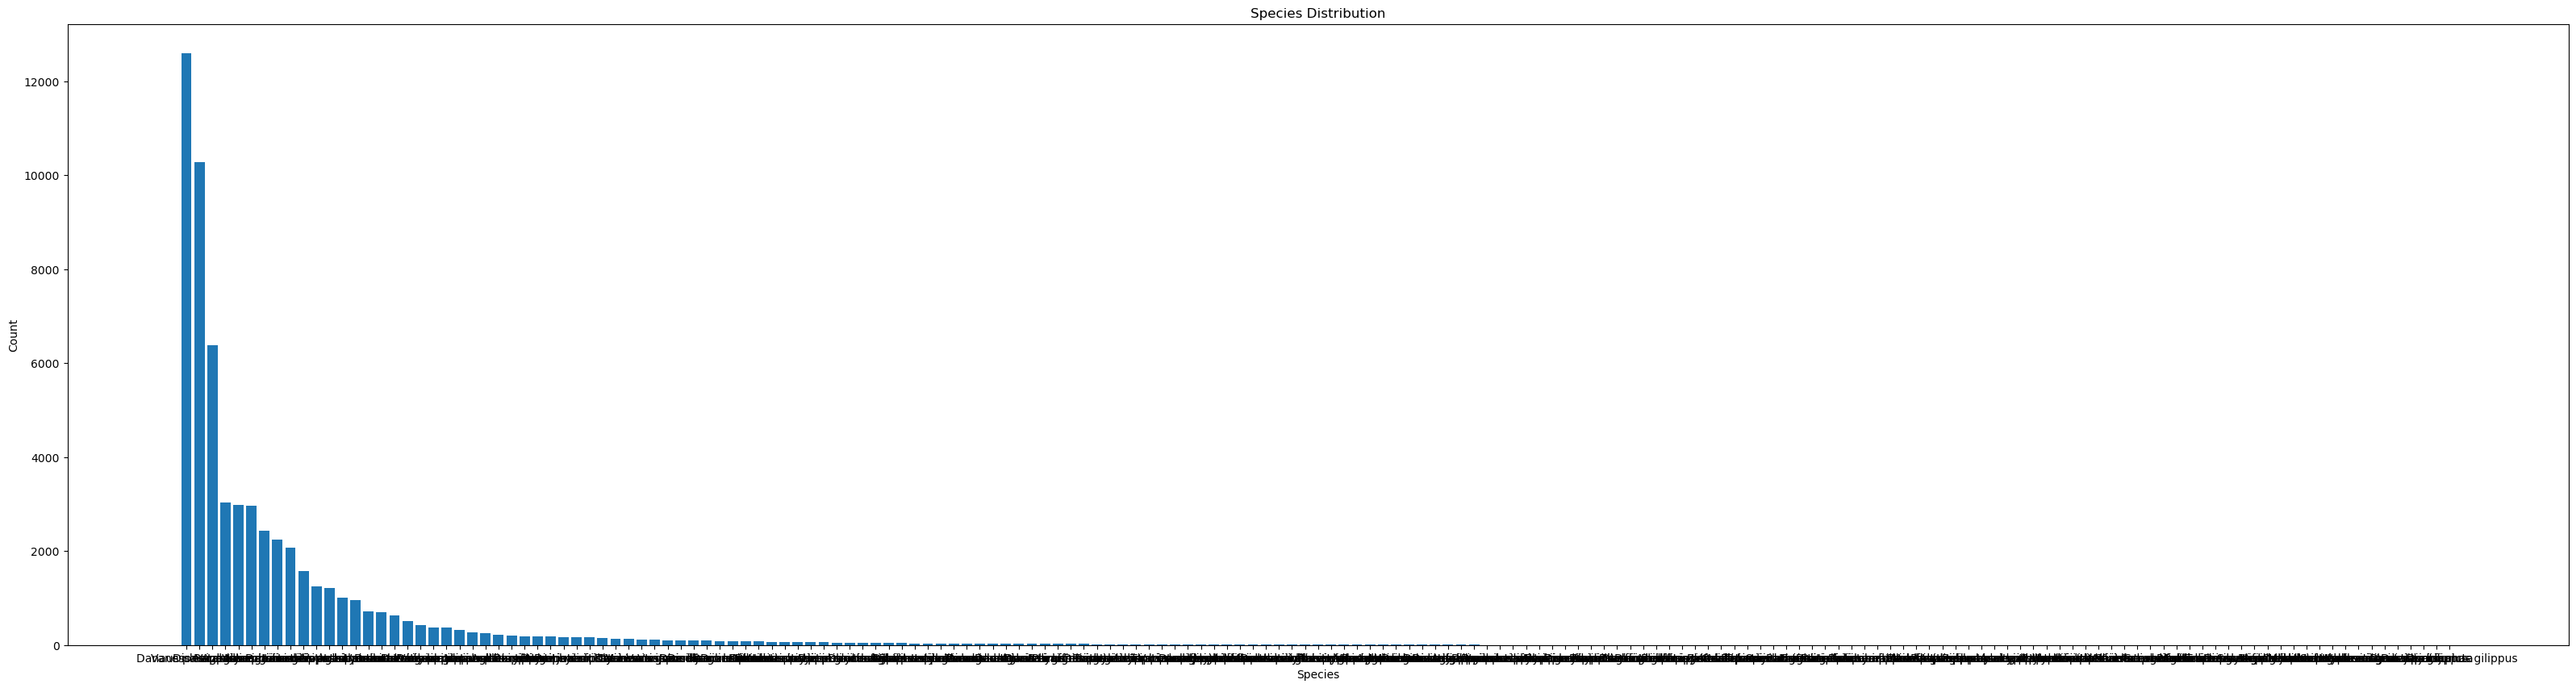

In [6]:
import matplotlib.pyplot as plt 
plt.figure(figsize=(40, 10))
plt.bar(count_species.keys(), count_species.values) 
plt.xlabel("Species") 
plt.ylabel("Count") 
plt.title("Species Distribution") 
plt.show() 

### Plot a histogram of the top 9 species plus an "Other" category for the other species.

Use the training data set again.

In [7]:
# YOUR CHANGES HERE

top_nine = count_species[:9] 
top_nine

scientific_name
Danaus plexippus        12590
Vanessa atalanta        10271
Dione vanillae           6387
Aglais io                3027
Pararge aegeria          2988
Vanessa virginiensis     2969
Vanessa cardui           2440
Nymphalis antiopa        2243
Danaus gilippus          2077
Name: count, dtype: int64

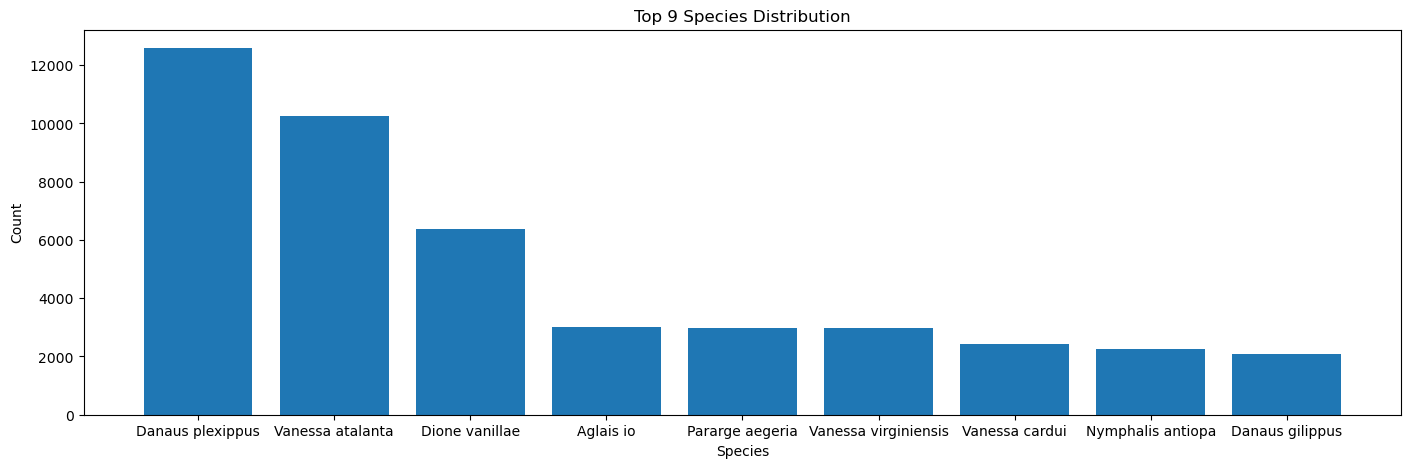

In [8]:
plt.figure(figsize=(17, 5))
plt.bar(top_nine.keys(), top_nine.values) 
plt.xlabel("Species") 
plt.ylabel("Count") 
plt.title("Top 9 Species Distribution") 
plt.show() 

### Write files "train-onehot.csv" and "validation-onehot.csv".

These will facilitate your data management later.
The columns for both files should be `uuid` and `image_path` from either "train.csv" or "validation.csv", followed by the top 9 species in the training data set in order, followed by `other`.
The values for the species and `other` columns should all be zero or one.

In [9]:
# YOUR CHANGES HERE

train_df = pd.read_csv('/projectnb/ds542/materials/butterflies/train.csv') 
validation_df = pd.read_csv('/projectnb/ds542/materials/butterflies/validation.csv') 

def make_one_hot(df, top_nine_species): 
    one_hot_array = [] 
    for species in df["scientific_name"]: 
        one_hot = [0] * 10 
        
        if species in top_nine_species: 
            i = top_nine_species.index(species) 
            one_hot[i] = 1 
        else: 
            one_hot[-1] = 1 

        one_hot_array.append(one_hot) 

    one_hot_df = pd.DataFrame(one_hot_array, columns = top_nine_species + ['other']) 
    
    return pd.concat([df[["uuid", "image_path"]].reset_index(drop=True), one_hot_df], axis = 1) 


    
train_onehot_df = make_one_hot(train_df, top_nine.keys().tolist())    
validation_onehot_df = make_one_hot(validation_df, top_nine.keys().tolist())   

train_onehot_df.to_csv("train-onehot.csv", index=False) 
validation_onehot_df.to_csv("validation-onehot.csv", index=False) 

In [10]:
pd.read_csv("train-onehot.csv").head(2) 

,uuid,image_path,Danaus plexippus,Vanessa atalanta,Dione vanillae,Aglais io,Pararge aegeria,Vanessa virginiensis,Vanessa cardui,Nymphalis antiopa,Danaus gilippus,other
0,5994c404-c52b-4833-ace9-eecdd76cf149,images-original/59/5994c404-c52b-4833-ace9-eec...,0,0,0,0,0,0,0,0,0,1
1,6cb21298-a76e-4693-abc5-c5ddea93ffbe,images-original/6c/6cb21298-a76e-4693-abc5-c5d...,0,0,0,0,0,0,0,0,1,0


Submit "train-onehot.csv" and "validation-onehot.csv" in Gradescope.

Comment: The onehot encoding into files could have been skipped and instead the onehot encoding could have been handled by the DataSet subclass in part 2.
The auto-grader will check your files and give points after verifying their contents.
You should test submitting early to make sure that you have prepared the intended files.

## Part 2: Implement Torch DataSet and DataLoader objects to simplify data access.

[Homework 5](https://colab.research.google.com/github/DL4DS/fa2025/blob/main/static_files/assignments/homework5.ipynb) asked you to implement Torch [DataSet](https://docs.pytorch.org/docs/stable/data.html#torch.utils.data.Dataset) and [DataLoader](https://docs.pytorch.org/docs/stable/data.html#torch.utils.data.DataLoader) objects to separate data loading issues from the training logic.

Implement an appropriate DataSet subclass for the training and validation data.
The class constructor should take in a filename ("train.csv" or "validation.csv") and load the corresponding data.
The `__getitem__` method should return a tuple with a tensor of a single image data and a tensor with the onehot encoding of the target value.

In [11]:
# YOUR CHANGES HERE
from PIL import Image 

class ButterflyDataset(torch.utils.data.Dataset):
    def __init__(self, file_name, top_nine_species, transform=None, target_transform=None):
        self.df = pd.read_csv('/projectnb/ds542/materials/butterflies/' + file_name) 
        self.transform = transform
        self.target_transform = target_transform 
        self.top_nine_species = top_nine_species 

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        image_path = '/projectnb/ds542/materials/butterflies/' + str(self.df.iloc[idx]["image_path"]) 
        image = Image.open(image_path).convert("RGB") 

        # label = index of top_nine_species + ['other'] 
        species = self.df.iloc[idx]["scientific_name"]  
        if species in self.top_nine_species: 
            label = self.top_nine_species.index(species) 
        else: 
            label = 9 

        label_tensor = torch.tensor(label, dtype=torch.long) 

        label_tensor_onehot = torch.nn.functional.one_hot(label_tensor, num_classes=10).float()     

        if self.transform:
            image = self.transform(image)
        if self.target_transform:
            label_tensor_onehot = self.target_transform(label_tensor_onehot) 
        
        return image, label_tensor_onehot         


Create a DataLoader object for the training data.

In [12]:
# YOUR CHANGES HERE 
from torch.utils.data import DataLoader 
import torchvision.transforms as T 

transform = T.Compose([
    T.RandomHorizontalFlip(p=0.5),
    T.RandomRotation(degrees=15),
    T.ToTensor()
]) 

top_nine_species = top_nine.keys().tolist()
train_dataset = ButterflyDataset("train.csv", top_nine_species, transform=transform) 
train_dataloader = DataLoader(train_dataset, batch_size=100, shuffle=True) 

Explain any non-default parameter choices you made for the DataLoader.

* batch_size = 100: load 100 images for each batch when training
* shuffle = True: shuffles the dataset at each epoch, because we want to prevent the model from memorizing or learning the order of samples. 

## Part 3: Define model structure and select an appropriate loss function.

Implement the model class for your convolutional neural network.
The final output of your model should be a tensor of probabilities for each of the ten species choices.

Hint: refer to [homework 5](https://colab.research.google.com/github/DL4DS/fa2025/blob/main/static_files/assignments/homework5.ipynb) and [project 1](https://colab.research.google.com/github/DL4DS/fa2025/blob/main/static_files/assignments/project1.ipynb) for examples.

In [13]:
def to_gpu(t):
    if torch.cuda.is_available():
        return t.cuda()
    return t

def to_numpy(t):
    return t.detach().cpu().numpy()

device = to_gpu(torch.ones(1,1)).device
device 

device(type='cuda', index=0)

In [14]:
for i in range(1, 10):
    img, label = train_dataset[i]
    print("TRAIN", img.shape, img.dtype)

TRAIN torch.Size([3, 500, 375]) torch.float32
TRAIN torch.Size([3, 500, 375]) torch.float32
TRAIN torch.Size([3, 500, 375]) torch.float32
TRAIN torch.Size([3, 500, 375]) torch.float32
TRAIN torch.Size([3, 500, 375]) torch.float32
TRAIN torch.Size([3, 500, 375]) torch.float32
TRAIN torch.Size([3, 500, 375]) torch.float32
TRAIN torch.Size([3, 500, 375]) torch.float32
TRAIN torch.Size([3, 500, 375]) torch.float32


In [15]:
# YOUR CHANGES HERE

class ButterflyNetwork(torch.nn.Module):
            
    def __init__(self):
        super().__init__()        
        self.layer1 = torch.nn.Sequential(
            torch.nn.Conv2d(3, 8, kernel_size=3, stride=1, padding=1),
            torch.nn.ReLU(),
            torch.nn.BatchNorm2d(8),
            torch.nn.MaxPool2d(2, 2),
            torch.nn.Dropout(0.1)
        )
        self.layer2 = torch.nn.Sequential(
            torch.nn.Conv2d(8, 16, kernel_size=3, stride=1, padding=1),
            torch.nn.ReLU(),
            torch.nn.BatchNorm2d(16),
            torch.nn.MaxPool2d(2, 2),
            torch.nn.Dropout(0.1)
        )
        self.layer3 = torch.nn.Sequential(
            torch.nn.Conv2d(16, 32, kernel_size=3, stride=1, padding=1),
            torch.nn.ReLU(),
            torch.nn.BatchNorm2d(32),
            torch.nn.MaxPool2d(2, 2),
            torch.nn.Dropout(0.1)
        )

        self.layer4 = torch.nn.Sequential(
            torch.nn.Conv2d(32, 64, kernel_size=3, stride=1, padding=1),
            torch.nn.ReLU(),
            torch.nn.BatchNorm2d(64),
            torch.nn.MaxPool2d(2, 2), 
            torch.nn.Dropout(0.1)
        )

        self.layer5 = torch.nn.Sequential(
            torch.nn.Conv2d(64, 128, kernel_size=3, stride=1, padding=1),
            torch.nn.ReLU(),
            torch.nn.BatchNorm2d(128),
            torch.nn.MaxPool2d(2, 2), 
            torch.nn.Dropout(0.1)
        )

        self.dropout_1 = torch.nn.Dropout(0.25)  
        self.maxpool = torch.nn.AdaptiveMaxPool2d(1)

        self.fc_1 = torch.nn.Linear(128, 10) 
        # self.dropout_2 = torch.nn.Dropout(0.4)
        # self.fc_3 = torch.nn.Linear(128, 10) 

        

    def forward(self, x):
        X = self.layer1(x)
        X = self.layer2(X)
        X = self.layer3(X)
        X = self.layer4(X)
        X = self.layer5(X)

        X = self.dropout_1(X)   
        X = self.maxpool(X)
        X = X.view(X.size(0), -1)
        
        X = self.fc_1(X)
        # X.torch.nn.functional.relu(X) 
        # X = self.dropout_2(X) 
        
        # X = self.fc_2(X) 

        return X 

# test_model = ButterflyNetwork().to(device)

Explain your choices for the shapes in each convolutional layer of your model.

* I added Conv2d to extract features 
* I added Relu as activation function to adds non-linearity and allow the model to learn complex patterns 
* I added BatchNorm2d to speed up convergence and improve regularization 
* I added MaxPool2d to reduce size of parameters 
* I added Dropout to improve regularization and prevent overfitting 

* I used kernel_size=3, stride=1 and padding-1 to preserve spatial size and capture local features efficiently 

Explain your choices for the channels in each convolutional layer of your model.

* input size for channel for layer 1: 3×500×375, hence in_channel = 3. out_channel = 8 to allow the layer to capture more complex and abstract features 
* input size for channel for layer 2: 8×250×187, hence in_channel = 8. out_channel = 16 to allow the layer to capture more complex and abstract features 
* input size for channel for layer 3: 16×125×93, hence in_channel = 16. out_channel = 32 to allow the layer to capture more complex and abstract features 
* input size for channel for layer 4: 32×62×46, hence in_channel = 32. out_channel = 64 to allow the layer to capture more complex and abstract features 
* input size for channel for layer 5: 64×31×23, hence in_channel = 64. out_channel = 128 to allow the layer to capture more complex and abstract features 


Pick and define a loss function for your model.
Feel free to use an existing Torch function.

In [16]:
# YOUR CHANGES HERE
loss_function = torch.nn.CrossEntropyLoss() 

Explain your choice of loss function.
One sentence should suffice.

* It is because the CrossEntropyLoss measures the difference between the predicted class probabilities and the true class labels. 

## Part 4: Implement a training loop and explain your choices.

Implement and run an appropriate training loop.
Plot accuracy and loss for the training and validation sets for each epoch.
Plot a summary of the gradients of your choice for each epoch.

* To prevent overfitting and have a more stable training process, I applied data augmentation, early stopping, weight decay, kaiming normal initialization, and scheduler.
* During training, for each epoch I first iterate through the training data, calculated the loss, and update the model. Then I evaluated the performance of the updated model and updated the scheduler. 

In [17]:
import copy
from torch.utils.data import TensorDataset, DataLoader 
import numpy as np 

In [18]:
transform_train = T.Compose([
    T.RandomHorizontalFlip(),
    T.RandomRotation(30),
    T.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.1),
    T.ToTensor(),  
    T.Normalize(mean=[0.485, 0.456, 0.406],
                std=[0.229, 0.224, 0.225])
]) 

transform_val = T.Compose([
    T.ToTensor(),  
    T.Normalize(mean=[0.485, 0.456, 0.406],
                std=[0.229, 0.224, 0.225])
]) 

# subset_size = 10000
train_dataset = ButterflyDataset("train.csv", top_nine_species, transform=transform_train) 
# small_train_dataset = torch.utils.data.Subset(train_dataset, range(min(subset_size, len(train_dataset))))
train_loader = DataLoader(train_dataset, batch_size=128, shuffle=True)  

val_dataset = ButterflyDataset("validation.csv", top_nine_species, transform=transform_val) 
# small_val_dataset = torch.utils.data.Subset(val_dataset, range(min(subset_size, len(val_dataset))))
val_loader = DataLoader(val_dataset, batch_size=128) 

In [28]:
print(f"Training on {len(train_dataset)} samples")
print(f"Validating on {len(val_dataset)} samples")

Training on 59751 samples
Validating on 10000 samples


In [ ]:
# YOUR CHANGES HERE 
import time 

def init_weights_kaiming_normal(m): 
    if isinstance(m, (torch.nn.Conv2d, torch.nn.Linear)): 
        torch.nn.init.kaiming_normal_(m.weight, nonlinearity='relu') 
        if m.bias is not None: 
            torch.nn.init.constant_(m.bias, 0) 

train_losses_checkpoint, val_losses_checkpoint = [], [] 
train_accuracies_checkpoint, val_accuracies_checkpoint = [], [] 
gradients_checkpoint = [] 

def train_eval(model_class, loss_function, epochs=1000, 
                                 early_stopping=True, 
                                 kaiming_normal_init=True, 
                                 patience=300, 
                                 learning_rate=1e-4, 
                                 weight_decay_lamb=1e-2, 
                                 model_name="butterfly_model"): 

    # initialize the model 
    if kaiming_normal_init:
        model = model_class()
        model.apply(init_weights_kaiming_normal)
    else:
        model = model_class() 
        
    model = model.to(device) 
     
    # setup the optimizer and criterion 
    optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate, weight_decay=weight_decay_lamb) 
    criterion = loss_function 
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=30)
    scaler = torch.cuda.amp.GradScaler()

    train_losses, val_losses = [], [] 
    train_accuracies, val_accuracies = [], [] 
    gradients = [] 
    
    best_val_loss = float('inf') 
    best_epoch = -1 
    best_model_state = None 
    best_model_performance = None
    epochs_no_improve = 0 

    for epoch in range(epochs):
        # start = time.time()
        model.train()
        train_loss = 0 
        train_correct = 0
        for X, y in train_loader:
            X, y = X.to(device), y.to(device) 
            y_label = torch.argmax(y, dim=1)
            
            optimizer.zero_grad()
            with torch.cuda.amp.autocast():
                out = model(X)
                loss = criterion(out, y_label) 
            scaler.scale(loss).backward()
            scaler.step(optimizer)
            scaler.update()
            
            train_loss += loss.item() 
            train_pred = torch.argmax(out, dim=1) 
            
            train_correct += (train_pred == y_label).sum().item() 
            
            # loss.backward()
            # optimizer.step()
        scheduler.step()
        train_loss = train_loss / len(train_loader)
        train_accuracy = train_correct / len(train_dataset)
        train_losses.append(train_loss)
        train_accuracies.append(train_accuracy) 

        # Evaluate
        model.eval()
        val_loss = 0 
        val_correct = 0 
        with torch.no_grad():
            for X, y in val_loader:
                X, y = X.to(device), y.to(device) 
                y_label = torch.argmax(y, dim=1) 
                
                out = model(X)
                val_loss += criterion(out, y_label).item() 
                val_pred = torch.argmax(out, dim=1) 
                val_correct += (val_pred == y_label).sum().item()
        val_loss = val_loss / len(val_loader) 
        val_accuracy = val_correct / len(val_dataset) 
        val_losses.append(val_loss) 
        val_accuracies.append(val_accuracy) 

        grads = [] 
        for _, p in model.named_parameters(): 
            if p.grad is not None: 
                grads.append(p.grad.abs().mean().item()) 
        gradients.append(np.mean(grads)) 

        
        # Early Stopping 
        if early_stopping: 
            if val_loss < best_val_loss:
                best_val_loss = val_loss 
                best_epoch = epoch
                best_model_state = copy.deepcopy(model.state_dict()) 
                best_model_performance = {
                    'train_loss': train_loss,
                    'val_loss': val_loss,
                    'train_acc': train_accuracy,
                    'val_acc': val_accuracy
                }
                epochs_no_improve = 0
            else:
                epochs_no_improve += 1
    
            if epochs_no_improve >= patience:
                print(f"Stopped training beacuse model did not improve for {patience} epochs")
                break 
        else:
            if val_loss < best_val_loss:
                best_val_loss = val_loss
                best_epoch = epoch
                best_model_state = copy.deepcopy(model.state_dict())
        print(f"Epoch {epoch+1}/{epochs} - train_loss: {train_loss:.4f}, val_loss: {val_loss:.4f}, train_acc: {train_accuracy:.4f}, val_acc: {val_accuracy:.4f}") 
        # print(f"Epoch {epoch} done")

        # torch.save(model.state_dict(), 'checkpoint.pth') 
        train_losses_checkpoint = train_losses
        val_losses_checkpoint = val_losses 
        train_accuracies_checkpoint = train_accuracies
        val_accuracies_checkpoint = val_accuracies 
        gradients_checkpoint = gradients 

    if best_model_performance is not None:
        print(f"Performance of final model- train_loss: {best_model_performance['train_loss']:.4f}, val_loss: {best_model_performance['val_loss']:.4f}, train_acc: {best_model_performance['train_acc']:.4f}, val_acc: {best_model_performance['val_acc']:.4f}")
    else: 
        print(f"Performance of final model - train_loss: {train_losses[-1]:.4f}, val_loss: {val_losses[-1]:.4f}, train_acc: {train_accuracies[-1]:.4f}, val_acc: {val_accuracies[-1]:.4f}")

    if early_stopping and best_model_state is not None:
        model.load_state_dict(best_model_state) 
        print(f"Loaded best model from epoch {best_epoch}") 
        
    torch.save(model.state_dict(), model_name + ".pt") 
    print(f"Model saved to {model_name}.pt") 

    # Plot the charts 
    plt.figure(figsize=(20,5))
    plt.subplot(1,3,1)
    plt.plot(train_losses, label="Train Loss")
    plt.plot(val_losses, label="Val Loss")
    if early_stopping:
        plt.axvline(best_epoch, linestyle='--', color='r', label='Early Stop Epoch')
    plt.title("Loss during training")
    plt.xlabel("Epochs")
    plt.ylabel("Loss")
    plt.legend()

    plt.subplot(1,3,2)
    plt.plot(train_accuracies, label="Train Accuracy")
    plt.plot(val_accuracies, label="Val Accuracy")
    if early_stopping:
        plt.axvline(best_epoch, linestyle='--', color='r', label='Early Stop Epoch')
    plt.title("Accuracy during training")
    plt.xlabel("Epochs")
    plt.ylabel("Accuracy")
    plt.legend() 

    plt.subplot(1,3,3)
    plt.plot(gradients) 
    plt.title("Average Gradient of Each Epoch") 
    plt.xlabel("Epoch") 

    plt.suptitle(f"Training: EarlyStop={early_stopping}, LearningRate = {learning_rate}")
    plt.show() 

    
    return model, train_losses, val_losses, train_accuracies, val_accuracies, gradients 

In [ ]:
loss_function = torch.nn.CrossEntropyLoss() 

model, train_losses, val_losses, train_accuracies, val_accuracies, gradients = train_eval(ButterflyNetwork, loss_function, epochs=80, 
                                 early_stopping=True, 
                                 kaiming_normal_init=True, 
                                 patience=7, 
                                 learning_rate=7e-3, 
                                 weight_decay_lamb=1e-3, 
                                 model_name="butterfly_model") 

/scratch/1276871.1.l40s/ipykernel_1481369/2240632621.py:35: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler()
/scratch/1276871.1.l40s/ipykernel_1481369/2240632621.py:57: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():


Epoch 1/80 - train_loss: 2.3117, val_loss: 1.6889, train_acc: 0.3027, val_acc: 0.4074
Epoch 2/80 - train_loss: 1.6077, val_loss: 1.3690, train_acc: 0.4379, val_acc: 0.5334
Epoch 3/80 - train_loss: 1.4062, val_loss: 1.2245, train_acc: 0.5096, val_acc: 0.5920
Epoch 4/80 - train_loss: 1.3004, val_loss: 1.2384, train_acc: 0.5463, val_acc: 0.5927
Epoch 5/80 - train_loss: 1.2258, val_loss: 1.1244, train_acc: 0.5763, val_acc: 0.6343
Epoch 6/80 - train_loss: 1.1872, val_loss: 1.0959, train_acc: 0.5891, val_acc: 0.6533
Epoch 7/80 - train_loss: 1.1590, val_loss: 1.0842, train_acc: 0.5983, val_acc: 0.6546
Epoch 8/80 - train_loss: 1.1338, val_loss: 1.0513, train_acc: 0.6068, val_acc: 0.6650
Epoch 9/80 - train_loss: 1.1176, val_loss: 0.9977, train_acc: 0.6148, val_acc: 0.6776
Epoch 10/80 - train_loss: 1.0906, val_loss: 0.9522, train_acc: 0.6238, val_acc: 0.6982
Epoch 11/80 - train_loss: 1.0734, val_loss: 0.9602, train_acc: 0.6302, val_acc: 0.6899
Epoch 12/80 - train_loss: 1.0540, val_loss: 0.9402, 

## Part 5: Predict species for the test set.

Use your model to predict probabilities for each of the species choices.

**SCC runs extremely slowly - it took about 15 minutes to train just one epoch. I worked on training throughout the entire night, but SCC shut down while I took a short break. I didn’t have time to retrain, so I loaded the latest saved checkpoint. As a result, the model hasn’t converged because training was interrupted before completion. I’ve done my best under these constraints.**

In [32]:
# YOUR CHANGES HERE
checkpoint = torch.load('checkpoint_butterfly.pth', weights_only=False)
test_model = ButterflyNetwork().to(device) 
test_model.load_state_dict(checkpoint['model_state_dict'])
train_losses = checkpoint['train_losses']
val_losses = checkpoint['val_losses']

train_accuracies = checkpoint['train_accuracies']
val_accuracies = checkpoint['val_accuracies']
gradients = checkpoint['gradients']

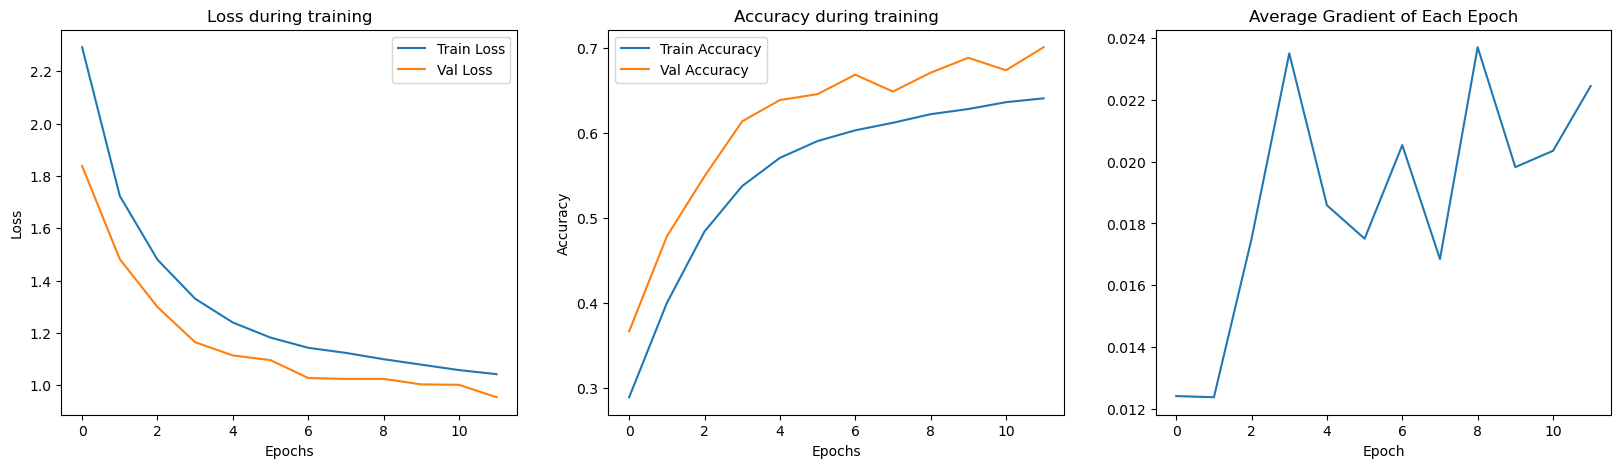

In [34]:
plt.figure(figsize=(20,5))
plt.subplot(1,3,1)
plt.plot(train_losses, label="Train Loss")
plt.plot(val_losses, label="Val Loss")

plt.title("Loss during training")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()

plt.subplot(1,3,2)
plt.plot(train_accuracies, label="Train Accuracy")
plt.plot(val_accuracies, label="Val Accuracy")

plt.title("Accuracy during training")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend() 

plt.subplot(1,3,3)
plt.plot(gradients) 
plt.title("Average Gradient of Each Epoch") 
plt.xlabel("Epoch") 

plt.show() 

In [35]:
val_iter = iter(val_loader)

X, y = next(val_iter)

X, y = X.to(device), y.to(device)

test_model.eval()
with torch.no_grad():
    out = test_model(X)  
    preds = torch.argmax(out, dim=1)   
    labels = torch.argmax(y, dim=1)    

for idx in range(20):   
    print("Predicted class for image:", preds[idx].item())
    print("True class for image:     ", labels[idx].item())

Predicted class for image: 5
True class for image:      5
Predicted class for image: 9
True class for image:      9
Predicted class for image: 1
True class for image:      1
Predicted class for image: 1
True class for image:      1
Predicted class for image: 9
True class for image:      9
Predicted class for image: 5
True class for image:      5
Predicted class for image: 0
True class for image:      0
Predicted class for image: 0
True class for image:      0
Predicted class for image: 9
True class for image:      8
Predicted class for image: 9
True class for image:      9
Predicted class for image: 1
True class for image:      1
Predicted class for image: 1
True class for image:      1
Predicted class for image: 5
True class for image:      6
Predicted class for image: 0
True class for image:      0
Predicted class for image: 5
True class for image:      9
Predicted class for image: 9
True class for image:      9
Predicted class for image: 8
True class for image:      8
Predicted clas

In [46]:
# YOUR CHANGES HERE
from PIL import Image 
import torch
import torch.nn.functional as F
from torchvision import transforms
import pandas as pd

df = pd.read_csv('/projectnb/ds542/materials/butterflies/test.csv') 
print(df.shape)
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

test_model.eval()

for idx in range(20):
    image_path = '/projectnb/ds542/materials/butterflies/' + str(df.iloc[idx]["image_path"])
    image = Image.open(image_path).convert("RGB")
    image = transform(image).unsqueeze(0).to(device)  

    with torch.no_grad():
        out = test_model(image)
        probs = torch.nn.functional.softmax(out, dim=1)
        pred_class = torch.argmax(probs, dim=1).item()

    print(f"Image {idx}: predicted class = {pred_class}, probs = {probs.cpu().numpy().round(3)}")


(10000, 2)
Image 0: predicted class = 2, probs = [[0.068 0.028 0.492 0.068 0.097 0.055 0.018 0.034 0.025 0.116]]
Image 1: predicted class = 2, probs = [[0.054 0.119 0.322 0.073 0.049 0.064 0.047 0.033 0.033 0.206]]
Image 2: predicted class = 2, probs = [[0.048 0.102 0.443 0.023 0.012 0.061 0.02  0.01  0.021 0.261]]
Image 3: predicted class = 2, probs = [[0.021 0.06  0.557 0.016 0.028 0.033 0.005 0.022 0.037 0.221]]
Image 4: predicted class = 2, probs = [[0.01  0.013 0.824 0.009 0.008 0.017 0.006 0.003 0.005 0.105]]
Image 5: predicted class = 2, probs = [[0.007 0.009 0.391 0.009 0.04  0.173 0.017 0.01  0.006 0.339]]
Image 6: predicted class = 2, probs = [[0.107 0.058 0.442 0.012 0.039 0.067 0.027 0.013 0.055 0.18 ]]
Image 7: predicted class = 2, probs = [[0.197 0.007 0.468 0.005 0.004 0.055 0.003 0.009 0.036 0.216]]
Image 8: predicted class = 9, probs = [[0.131 0.066 0.142 0.07  0.024 0.169 0.039 0.082 0.023 0.255]]
Image 9: predicted class = 2, probs = [[0.07  0.174 0.311 0.025 0.02  0

Save your predictions to "test-predictions.csv" with columns `uuid`, the top 9 species and `other`.

In [47]:
# YOUR CHANGES HERE
import pandas as pd
import torch
from PIL import Image
from torchvision import transforms
import torch.nn.functional as F

test_df = pd.read_csv('/projectnb/ds542/materials/butterflies/test.csv')
top_nine_species = list(top_nine.keys())  
cols = ["uuid"] + top_nine_species + ["other"]

transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

test_model.eval()
rows = []

for idx, row in test_df.iterrows():
    image_path = '/projectnb/ds542/materials/butterflies/' + row["image_path"]
    image = Image.open(image_path).convert("RGB")
    image = transform(image).unsqueeze(0).to(device)

    with torch.no_grad():
        out = test_model(image)                 
        pred_class = int(torch.argmax(out, dim=1).item())  

    one_hot = [0]*10
    if pred_class < 10:
        one_hot[pred_class] = 1
    else:
        one_hot[-1] = 1

    rows.append([row["uuid"]] + one_hot)

test_pred_df = pd.DataFrame(rows, columns=cols)
test_pred_df.to_csv("test-predictions.csv", index=False)
print("Saved to test-predictions.csv")


Saved to test-predictions.csv


Submit "test-predictions.csv" to Gradescope.

## Part 6: Submit Your Notebook

Submit your notebook to Gradescope.

## Follow Up

Make sure to check the immediate auto-grader feedback in Gradescope.
It will let you know if your file formats are correct and help you catch some avoidable mistakes.